# The Anatomy of Market Returns

### A quantitative study of return, risk, correlation, distributions, and drawdowns

**Research question:** How different are financial assets when we measure their behaviour through returns, volatility, correlation, distributions, and drawdowns rather than simply comparing price charts?

This notebook runs in Google Colab, uses publicly available data, and is **deterministic**: the sample end date is fixed, and the downloaded data is saved to `data/market_data.csv` on the first run and re-used afterwards.

## 1. Research design

We compare five broad market exposures, **all measured in U.S. dollars and on a total-return basis wherever Yahoo Finance offers it**:

| Asset | Series | Return basis |
|---|---|---|
| NIFTY 50 | `^NSEI` converted with `INR=X` | Price index (dividends not included) |
| S&P 500 | `^SP500TR` (fallback `^GSPC`) | Total return (fallback: price only) |
| Gold | `GLD` | ETF, net of fees |
| U.S. Treasuries | `TLT` | Total return (dividend-adjusted) |
| Bitcoin | `BTC-USD` | Spot |

Two supporting series are downloaded: `INR=X` (USD/INR, to put NIFTY in dollars) and `^IRX` (13-week T-bill yield, used as the risk-free rate).

The goal is descriptive rather than predictive.

### Questions answered in the Findings section

* **Q1.** Which asset compounded the most, and which the least?
* **Q2.** Did higher volatility come with higher returns?
* **Q3.** Which assets suffered the deepest drawdowns?
* **Q4.** Which assets moved least with the others (potential diversifiers), and is that stable over time?
* **Q5.** How heavy are the tails, and are returns consistent with a normal distribution?
* **Q6.** Does the ranking of assets depend on the performance measure used?


In [4]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.2})

# ---- Configuration -------------------------------------------------------
DOWNLOAD_START = "2014-01-01"   # the analysis itself starts when ALL series exist
END = "2026-09-30"              # fixed so results do not drift between runs
SNAPSHOT = Path("data/market_data.csv")

TICKERS = {
    "NIFTY 50": "^NSEI",        # INR price index
    "S&P 500": "^SP500TR",      # total-return index
    "Gold": "GLD",
    "U.S. Treasuries": "TLT",
    "Bitcoin": "BTC-USD",
    "USDINR": "INR=X",
    "T-bill yield": "^IRX",     # percent, annualised
}
ASSETS = ["NIFTY 50", "S&P 500", "Gold", "U.S. Treasuries", "Bitcoin"]

# ---- Working-directory check ---------------------------------------------
# SNAPSHOT is relative to the current directory. Run from the repository root
# (in Colab: clone the repo and %cd into it first), otherwise the snapshot
# will be written somewhere that is not part of the repository.
if not Path("data").is_dir():
    print(f"WARNING: no 'data/' folder in {Path.cwd()}. Run from the repository root, "
          "or the snapshot will not end up inside the repository.")


## 2. Data acquisition

If `data/market_data.csv` exists it is used as-is (fully reproducible, works offline). Otherwise the data is downloaded from Yahoo Finance and the snapshot is written so it can be committed alongside the notebook.

`yfinance` pulls from an unofficial Yahoo endpoint, so occasional failures are normal; committing the snapshot is what makes the project robust.

**Running in Google Colab.** Colab starts in `/content`, not in your repository. Clone the repository and change into it first (`!git clone <repo-url>` then `%cd market-returns-risk-analysis`), or upload `data/market_data.csv` and `data/snapshot_info.json` into a `data/` folder. If the snapshot is created on the first run, download both files (`from google.colab import files; files.download(...)`) and commit them. Optionally run `%pip install -q -r requirements.txt` to match the pinned versions.


In [5]:
def download(tickers, start, end):
    import yfinance as yf  # imported lazily: not needed when a snapshot exists
    end_exclusive = (pd.Timestamp(end) + pd.Timedelta(days=1)).strftime("%Y-%m-%d")
    data = yf.download(
        list(tickers.values()), start=start, end=end_exclusive,
        auto_adjust=True, progress=False,
    )["Close"]
    data = data[list(tickers.values())]
    data.columns = list(tickers.keys())
    return data


import json

INFO = SNAPSHOT.with_name("snapshot_info.json")  # records how the snapshot was built
SP_BASIS = "total return (^SP500TR)"

if SNAPSHOT.exists():
    raw = pd.read_csv(SNAPSHOT, index_col=0, parse_dates=True)
    info = json.loads(INFO.read_text()) if INFO.exists() else {}
    SP_BASIS = info.get("sp500_basis", "unknown (no snapshot_info.json)")
    source = f"snapshot {SNAPSHOT} (downloaded {info.get('downloaded', 'unknown date')})"
else:
    raw = download(TICKERS, DOWNLOAD_START, END)
    if raw["S&P 500"].notna().sum() < 1000:  # total-return index unavailable
        fallback = download({"S&P 500": "^GSPC"}, DOWNLOAD_START, END)
        raw["S&P 500"] = fallback["S&P 500"]
        SP_BASIS = "PRICE ONLY (^GSPC; ^SP500TR was unavailable)"
        print("WARNING: S&P 500 total-return series unavailable; using price-only ^GSPC.")
    SNAPSHOT.parent.mkdir(parents=True, exist_ok=True)
    raw.to_csv(SNAPSHOT)
    INFO.write_text(json.dumps({"downloaded": str(pd.Timestamp.today().date()), "sp500_basis": SP_BASIS}))
    source = "Yahoo Finance (fresh download; snapshot saved)"

raw = raw.sort_index()
raw = raw.loc[:END]
missing = [c for c in TICKERS if c not in raw.columns or raw[c].dropna().empty]
assert not missing, f"No data for: {missing}"

print("Source:", source)
print("S&P 500 basis:", SP_BASIS)
print(raw.apply(lambda s: s.first_valid_index()).rename("First available date").to_frame())

Source: snapshot data/market_data.csv (downloaded 2026-10-05)
S&P 500 basis: total return (^SP500TR)
                First available date
NIFTY 50                  2014-01-02
S&P 500                   2014-01-02
Gold                      2014-01-02
U.S. Treasuries           2014-01-02
Bitcoin                   2014-09-17
USDINR                    2014-01-01
T-bill yield              2014-01-02


## 2A. Data quality checks

These checks deliberately run on the **raw download before the common-date inner join**. Missing observations are expected because markets have different calendars; the important question is whether a series is completely absent, duplicated, or contains invalid prices.


In [6]:
# Validate the raw market series before any rows are dropped.
asset_quality = pd.DataFrame({
    "First valid date": raw[ASSETS].apply(lambda s: s.first_valid_index()),
    "Missing observations": raw[ASSETS].isna().sum(),
    "Missing %": raw[ASSETS].isna().mean() * 100,
    "Non-positive observations": (raw[ASSETS] <= 0).sum(),
})
print(f"Raw rows: {len(raw):,}")
print(f"Duplicate timestamps: {raw.index.duplicated().sum():,}")
display(asset_quality)

assert raw.index.is_monotonic_increasing, "Raw data index is not sorted."
assert not raw.index.duplicated().any(), "Raw data contains duplicate timestamps."
assert not raw[ASSETS].isna().all().any(), "At least one asset has no observations at all."
assert not (raw[ASSETS] <= 0).any().any(), "At least one asset contains a non-positive price."

# Supporting series: they feed NIFTY-in-USD and every T-bill Sharpe ratio, so they are checked too.
aux = raw[["USDINR", "T-bill yield"]]
aux_quality = pd.DataFrame({
    "First valid date": aux.apply(lambda s: s.first_valid_index()),
    "Missing %": aux.isna().mean() * 100,
    "Minimum": aux.min(),
    "Maximum": aux.max(),
})
display(aux_quality)
assert not (raw["USDINR"].dropna() <= 0).any(), "USDINR contains a non-positive value."

# Outlier and stale-price screen (flags are prompts to look at the data, not proof of an error).
DEFAULT_LIMIT = 0.20                       # largest plausible move between consecutive observations
LIMITS = {"Bitcoin": 0.50, "USDINR": 0.05}
MAX_FLAT_RUN = 5                           # identical consecutive prices
rows = []
for c in ASSETS + ["USDINR"]:
    s = raw[c].dropna()
    moves = s.pct_change().dropna().abs()
    flat_run = int((s != s.shift()).cumsum().value_counts().max())
    limit = LIMITS.get(c, DEFAULT_LIMIT)
    rows.append({
        "Series": c, "Largest move": moves.max(), "Date": moves.idxmax(), "Limit": limit,
        "Longest flat run (obs)": flat_run,
        "Flag": "REVIEW" if (moves.max() > limit or flat_run > MAX_FLAT_RUN) else "ok",
    })
outlier_check = pd.DataFrame(rows).set_index("Series")
display(outlier_check)
if (outlier_check["Flag"] == "REVIEW").any():
    print("WARNING: inspect the flagged series; a single bad tick would distort kurtosis, worst loss and VaR.")


Raw rows: 4,582
Duplicate timestamps: 0


,First valid date,Missing observations,Missing %,Non-positive observations
NIFTY 50,2014-01-02,1450,31.6456,0
S&P 500,2014-01-02,1377,30.0524,0
Gold,2014-01-02,1377,30.0524,0
U.S. Treasuries,2014-01-02,1377,30.0524,0
Bitcoin,2014-09-17,185,4.0375,0


,First valid date,Missing %,Minimum,Maximum
USDINR,2014-01-01,27.5862,58.2780,96.8769
T-bill yield,2014-01-02,30.0742,-0.1050,5.3480


,Largest move,Date,Limit,Longest flat run (obs),Flag
Series,,,,,
NIFTY 50,0.1298,2020-03-23,0.2000,2,ok
S&P 500,0.1198,2020-03-16,0.2000,2,ok
Gold,0.1027,2026-01-30,0.2000,2,ok
U.S. Treasuries,0.0752,2020-03-20,0.2000,2,ok
Bitcoin,0.3717,2020-03-12,0.5000,2,ok
USDINR,0.0298,2020-04-02,0.0500,3,ok


### 2B. Currency, calendar and sampling choices

* **Currency.** NIFTY is quoted in rupees. Putting it beside dollar assets without conversion would mix equity returns with INR/USD moves, so NIFTY is converted to dollars using USD/INR (rupees per dollar, forward-filled across FX holidays). A local-currency robustness table appears later.
* **Calendar.** Markets close on different days and Bitcoin never closes. We keep only dates on which **all five** assets have a price (an inner join). Returns are then measured between consecutive common dates, so every asset's return covers the identical interval.
* **Annualisation.** Instead of hard-coding 252, we use the *actual* number of observations per year in this joined sample, so volatility annualisation is consistent for every asset including Bitcoin.

In [7]:
usdinr = raw["USDINR"].ffill()
usd = pd.DataFrame({
    "NIFTY 50": raw["NIFTY 50"] / usdinr,
    "S&P 500": raw["S&P 500"],
    "Gold": raw["Gold"],
    "U.S. Treasuries": raw["U.S. Treasuries"],
    "Bitcoin": raw["Bitcoin"],
})
nifty_inr = raw["NIFTY 50"]

n_before = len(usd.dropna(how="all"))
prices = usd.dropna()
nifty_inr = nifty_inr.reindex(prices.index)
tbill = (raw["T-bill yield"].ffill().reindex(prices.index) / 100)  # decimal, annualised

years = (prices.index[-1] - prices.index[0]).days / 365.25
returns = prices.pct_change().dropna()
ANN = len(returns) / years  # observations per year in THIS sample

# time gap (in years) covered by each return, used for the risk-free rate
gap_years = prices.index.to_series().diff().dt.days.iloc[1:] / 365.25
rf_rate = tbill.shift(1).reindex(returns.index)  # rate known at start of interval
n_rf_missing = int(rf_rate.isna().sum())
if n_rf_missing:
    print(f"WARNING: risk-free rate missing for {n_rf_missing} observations; treated as 0% for those intervals.")
rf_obs = (rf_rate * gap_years).fillna(0.0)

print(f"Common sample : {prices.index[0].date()} -> {prices.index[-1].date()}  ({years:.2f} years)")
print(f"Observations  : {len(returns):,} returns  ({ANN:.1f} per year; {n_before - len(prices):,} dates dropped by the inner join)")
prices.tail()

Common sample : 2014-09-17 -> 2026-09-30  (12.04 years)
Observations  : 2,871 returns  (238.5 per year; 1,707 dates dropped by the inner join)


,NIFTY 50,S&P 500,Gold,U.S. Treasuries,Bitcoin
Date,,,,,
2026-09-24,240.8900,"17,276.4609",391.6900,79.1014,"84,379.0625"
2026-09-25,240.6425,"17,364.7891",393.4100,79.0018,"84,034.9219"
2026-09-28,237.8187,"17,230.9492",377.9100,78.3046,"83,502.6094"
2026-09-29,236.6724,"17,202.1191",382.8900,77.9162,"83,622.4297"
2026-09-30,235.5053,"17,160.4102",380.8400,77.4680,"83,553.8516"


## 3. First look: price levels

Each series is normalised to 100 at the start of the common sample. Bitcoin dwarfs everything else, so the axis is **logarithmic**: equal vertical distances then mean equal percentage changes.

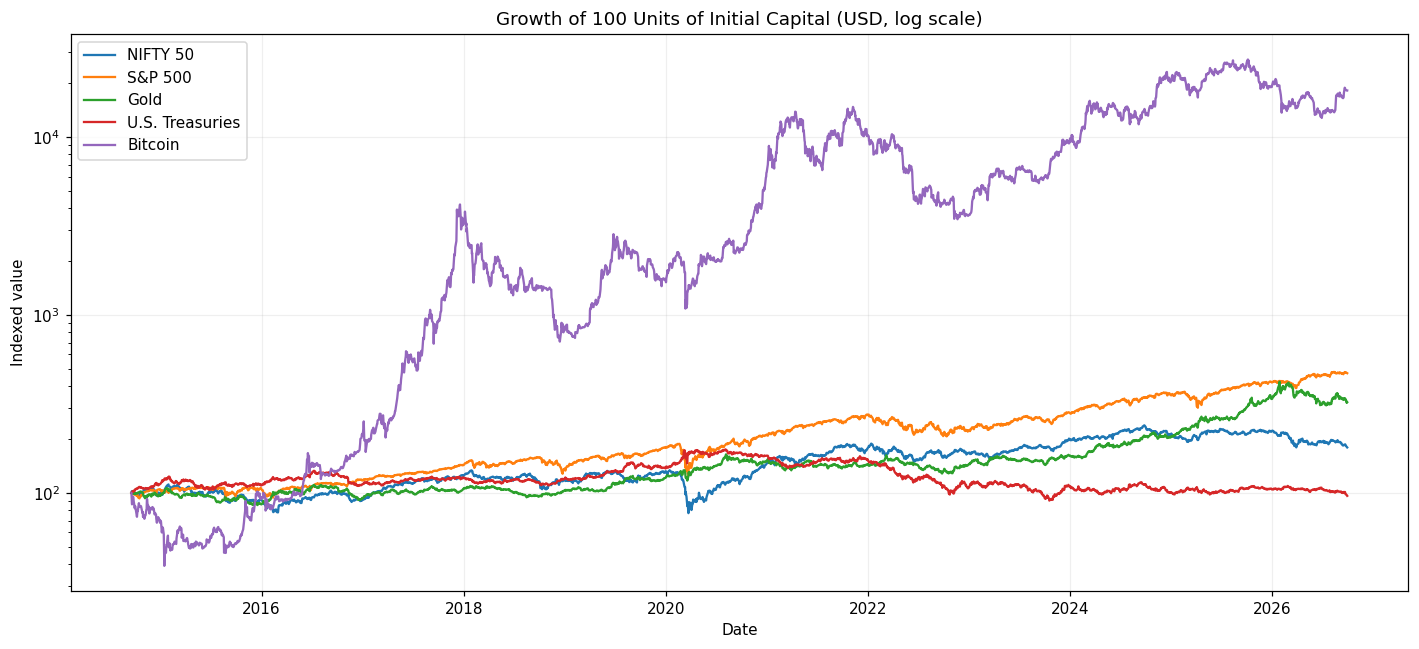

In [8]:
normalised = prices / prices.iloc[0] * 100

fig, ax = plt.subplots(figsize=(13, 6))
for c in normalised.columns:
    ax.plot(normalised.index, normalised[c], label=c)
ax.set_yscale("log")
ax.set(title="Growth of 100 Units of Initial Capital (USD, log scale)", ylabel="Indexed value", xlabel="Date")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Transform prices into returns

We use simple returns between consecutive common dates:

$$
r_t = \frac{P_t}{P_{t-1}} - 1
$$

### Two different "annual returns"

They answer different questions and the notebook reports both, clearly labelled:

* **Arithmetic annualised mean**, $\bar r \times N$ (with $N$ observations per year), is the right numerator for a Sharpe ratio, but it is **not** what an investor earned: it ignores volatility drag.
* **CAGR**, the compound annual growth rate, is what a buy-and-hold investor actually earned:

$$
\text{CAGR} = W_T^{\,1/\text{years}} - 1, \qquad W_T = \prod_{t=1}^{T}(1+r_t)
$$

For a highly volatile asset the two can differ enormously.

In [9]:
wealth = (1 + returns).cumprod()
# prepend the starting capital of 1.0 so drawdowns are measured from the true initial peak
wealth0 = pd.concat([pd.DataFrame(1.0, index=[prices.index[0]], columns=wealth.columns), wealth])

cagr = wealth0.iloc[-1] ** (1 / years) - 1
arith_mean = returns.mean() * ANN
vol = returns.std() * np.sqrt(ANN)

jb = returns.apply(lambda s: pd.Series([*stats.jarque_bera(s)], index=["JB stat", "JB p-value"]))

summary = pd.DataFrame({
    "CAGR": cagr,
    "Arithmetic annualised mean": arith_mean,
    "Annualised volatility": vol,
    "Skewness": returns.apply(stats.skew),
    "Excess kurtosis": returns.apply(lambda s: stats.kurtosis(s, fisher=True)),
    "Jarque-Bera p-value": jb.loc["JB p-value"],
})
summary.sort_values("CAGR", ascending=False)

,CAGR,Arithmetic annualised mean,Annualised volatility,Skewness,Excess kurtosis,Jarque-Bera p-value
Bitcoin,0.5414,0.6488,0.6545,-0.0476,6.6096,0.0000
S&P 500,0.1374,0.1439,0.1735,-0.3454,14.6204,0.0000
Gold,0.1026,0.1109,0.1626,-0.3737,6.2013,0.0000
NIFTY 50,0.0502,0.0649,0.1778,-0.6766,12.8616,0.0000
U.S. Treasuries,-0.0031,0.0076,0.1463,-0.1035,6.3388,0.0000


## 5. Cumulative performance

,Total cumulative return
Bitcoin,181.6977
S&P 500,3.7100
Gold,2.2401
NIFTY 50,0.8028
U.S. Treasuries,-0.0361


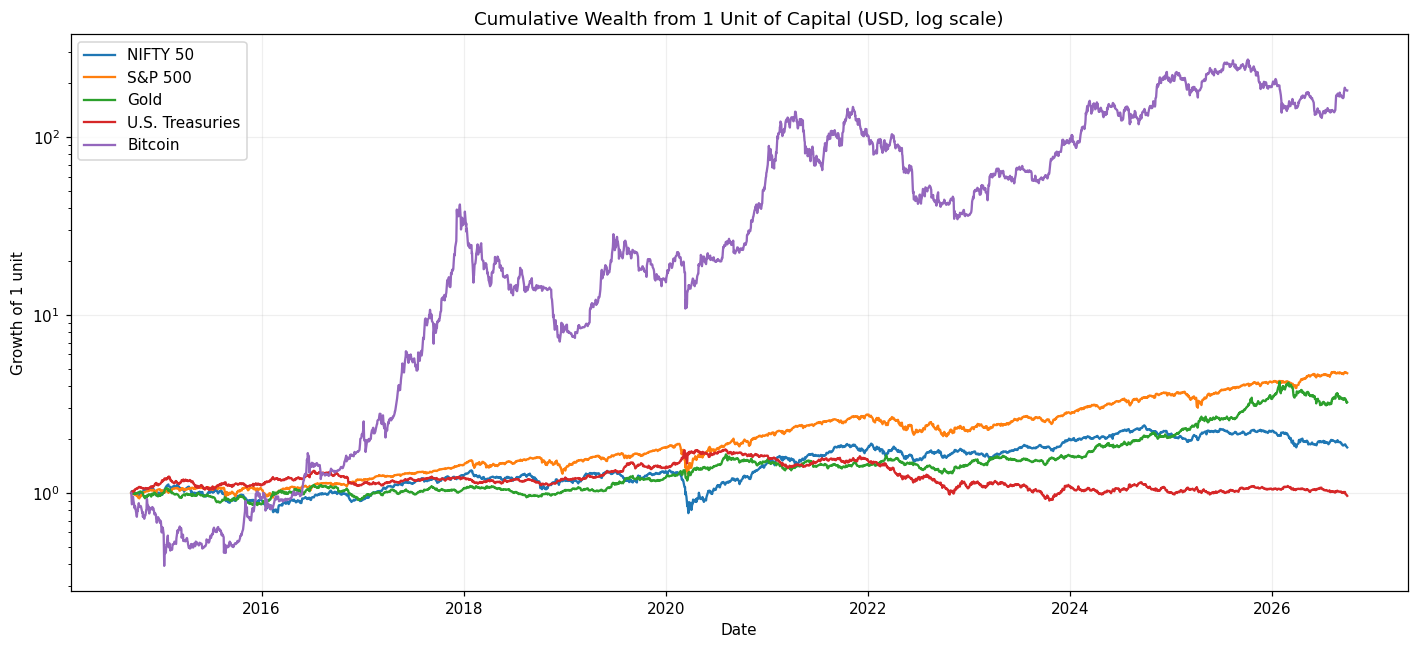

In [10]:
cumulative = (wealth0.iloc[-1] - 1).sort_values(ascending=False).to_frame("Total cumulative return")
display(cumulative)

fig, ax = plt.subplots(figsize=(13, 6))
for c in wealth0.columns:
    ax.plot(wealth0.index, wealth0[c], label=c)
ax.set_yscale("log")
ax.set(title="Cumulative Wealth from 1 Unit of Capital (USD, log scale)", ylabel="Growth of 1 unit", xlabel="Date")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Volatility

$$
\sigma_{\text{annual}} = \sigma_{\text{obs}}\sqrt{N}
$$

where $N$ is the observed number of returns per year in this sample (not a hard-coded 252). Volatility is not synonymous with risk, but it is a useful first measure of uncertainty.

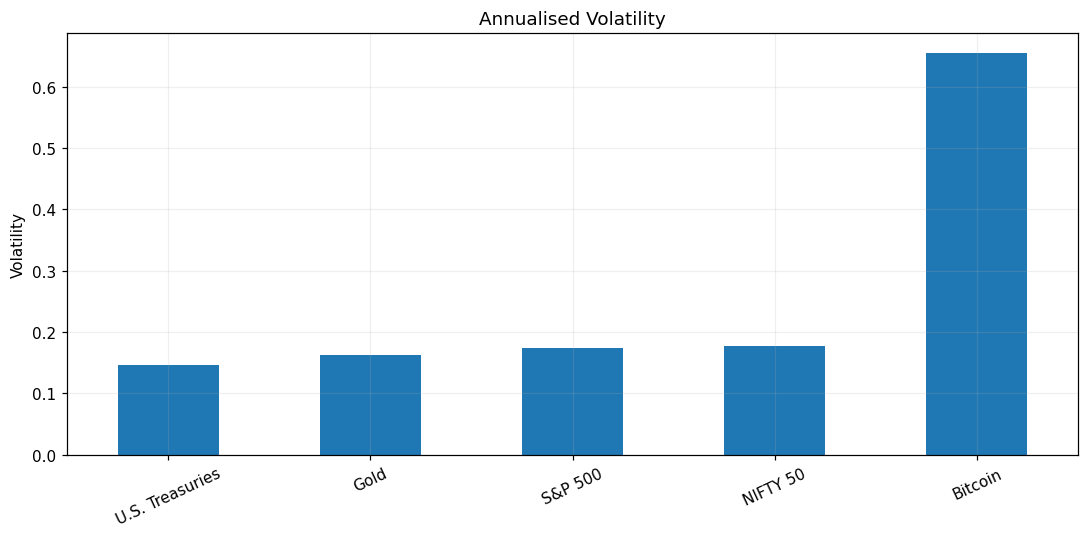

,Annualised volatility
Bitcoin,0.6545
NIFTY 50,0.1778
S&P 500,0.1735
Gold,0.1626
U.S. Treasuries,0.1463


In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
vol.sort_values().plot(kind="bar", ax=ax)
ax.set(title="Annualised Volatility", ylabel="Volatility", xlabel="")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

vol.sort_values(ascending=False).to_frame("Annualised volatility")

## 7. Rolling volatility

A single number hides changing conditions. The window is 63 observations, roughly three months.

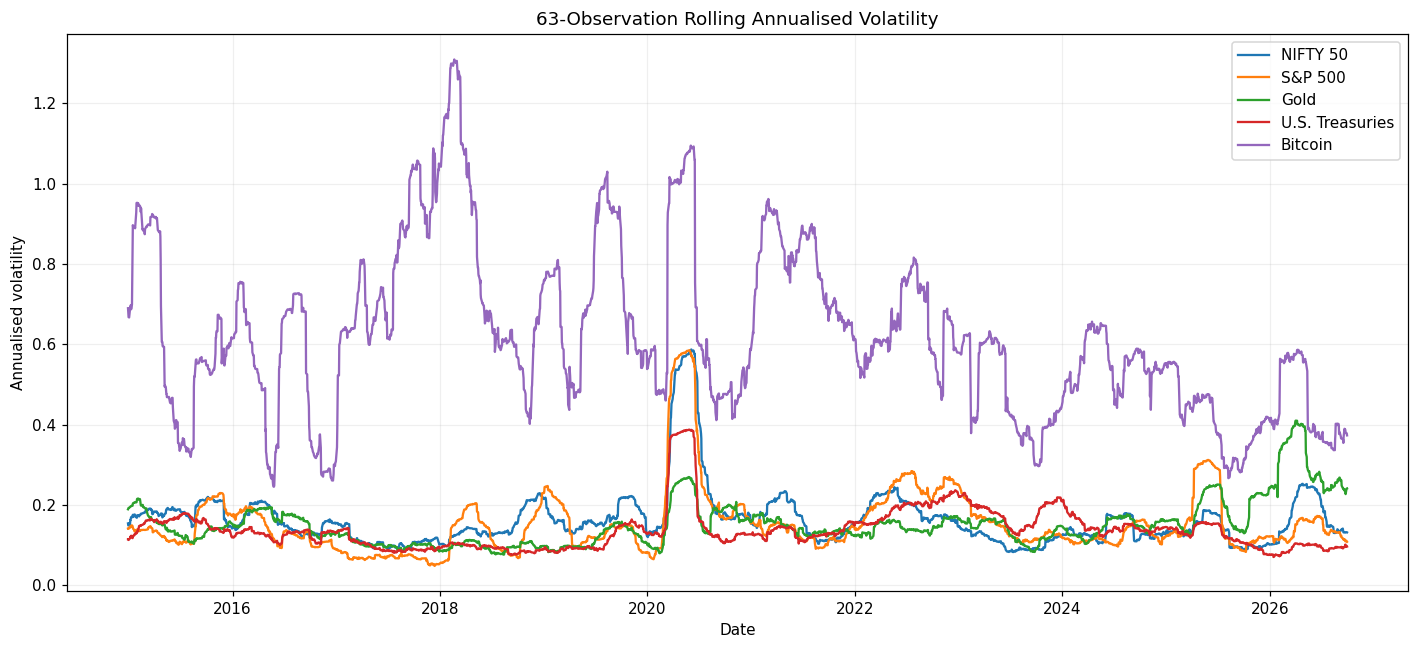

In [12]:
rolling_vol = returns.rolling(63).std() * np.sqrt(ANN)

fig, ax = plt.subplots(figsize=(13, 6))
for c in rolling_vol.columns:
    ax.plot(rolling_vol.index, rolling_vol[c], label=c)
ax.set(title="63-Observation Rolling Annualised Volatility", ylabel="Annualised volatility", xlabel="Date")
ax.legend()
plt.tight_layout()
plt.show()

## 8. Correlation

Correlation measures how return series move together. Low correlation does not automatically make a good diversifier, but it signals that combining assets can reduce portfolio volatility.

### Why we show daily *and* weekly

India closes (about 10:00 UTC) before the U.S. opens (about 13:30 UTC in summer, 14:30 UTC in winter), and Bitcoin's daily Yahoo "close" is at midnight UTC. A U.S. move on day *t* therefore shows up partly in NIFTY on day *t+1*. This **non-synchronous trading** biases same-day correlations toward zero. Weekly returns largely wash out the timing gap, so the weekly matrix is the fairer cross-market comparison. The lead-lag table below makes the effect visible.

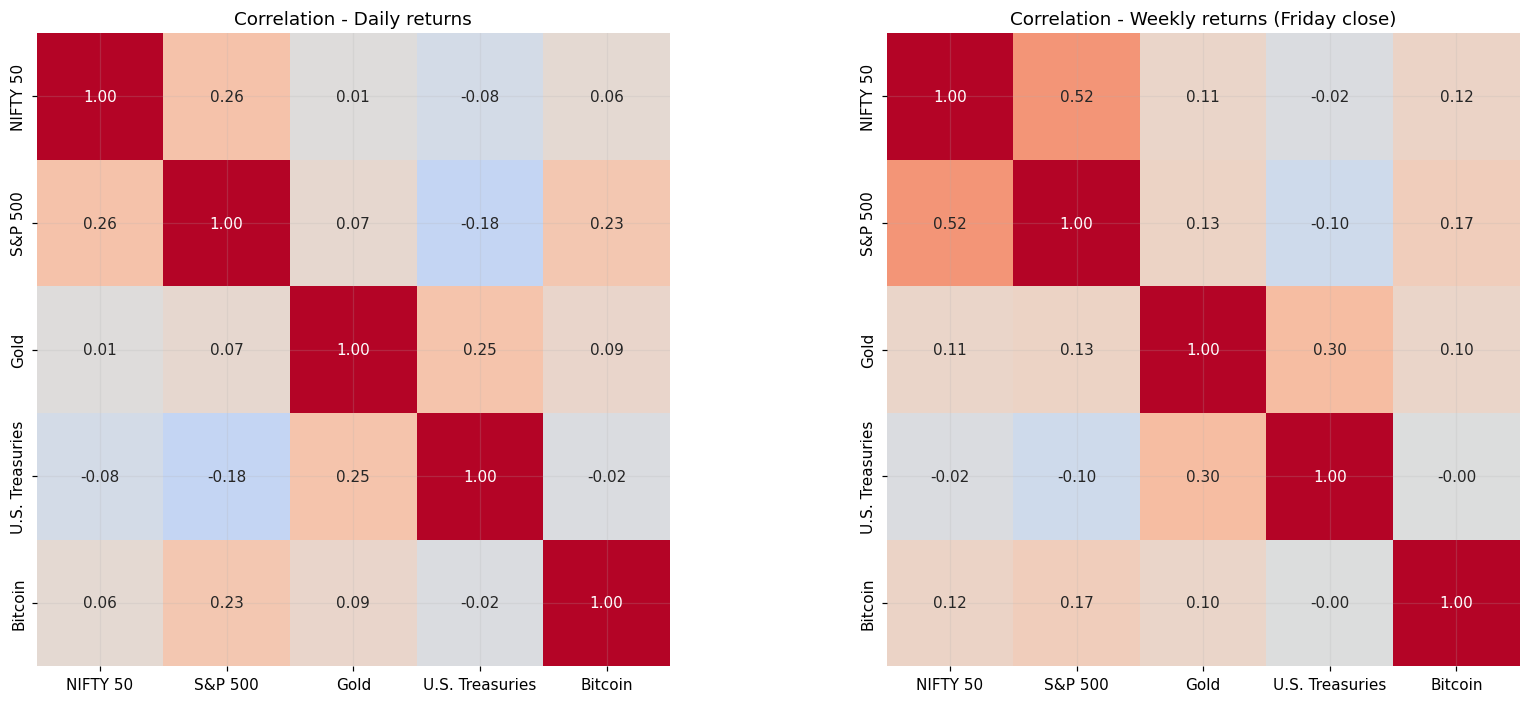

Weekly minus daily correlation (large positive values = daily understates co-movement):


,NIFTY 50,S&P 500,Gold,U.S. Treasuries,Bitcoin
NIFTY 50,0.0000,0.2600,0.1000,0.0600,0.0600
S&P 500,0.2600,0.0000,0.0600,0.0800,-0.0600
Gold,0.1000,0.0600,0.0000,0.0500,0.0100
U.S. Treasuries,0.0600,0.0800,0.0500,0.0000,0.0200
Bitcoin,0.0600,-0.0600,0.0100,0.0200,0.0000


In [13]:
weekly_prices = prices.resample("W-FRI").last().dropna()
weekly_returns = weekly_prices.pct_change().dropna()

corr_daily = returns.corr()
corr_weekly = weekly_returns.corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
for ax, m, t in zip(axes, [corr_daily, corr_weekly], ["Daily returns", "Weekly returns (Friday close)"]):
    sns.heatmap(m, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, square=True, cbar=False, ax=ax)
    ax.set_title(f"Correlation - {t}")
plt.tight_layout()
plt.show()

diff = (corr_weekly - corr_daily).round(2)
print("Weekly minus daily correlation (large positive values = daily understates co-movement):")
display(diff)

In [14]:
# Lead-lag: does the S&P 500 move on date t show up in NIFTY on t or t+1?
lead_lag = pd.DataFrame({
    "corr(NIFTY_t, S&P_t)": [returns["NIFTY 50"].corr(returns["S&P 500"])],
    "corr(NIFTY_t, S&P_t-1)": [returns["NIFTY 50"].corr(returns["S&P 500"].shift(1))],
}, index=["NIFTY vs S&P 500"])
lead_lag

,"corr(NIFTY_t, S&P_t)","corr(NIFTY_t, S&P_t-1)"
NIFTY vs S&P 500,0.2621,0.3162


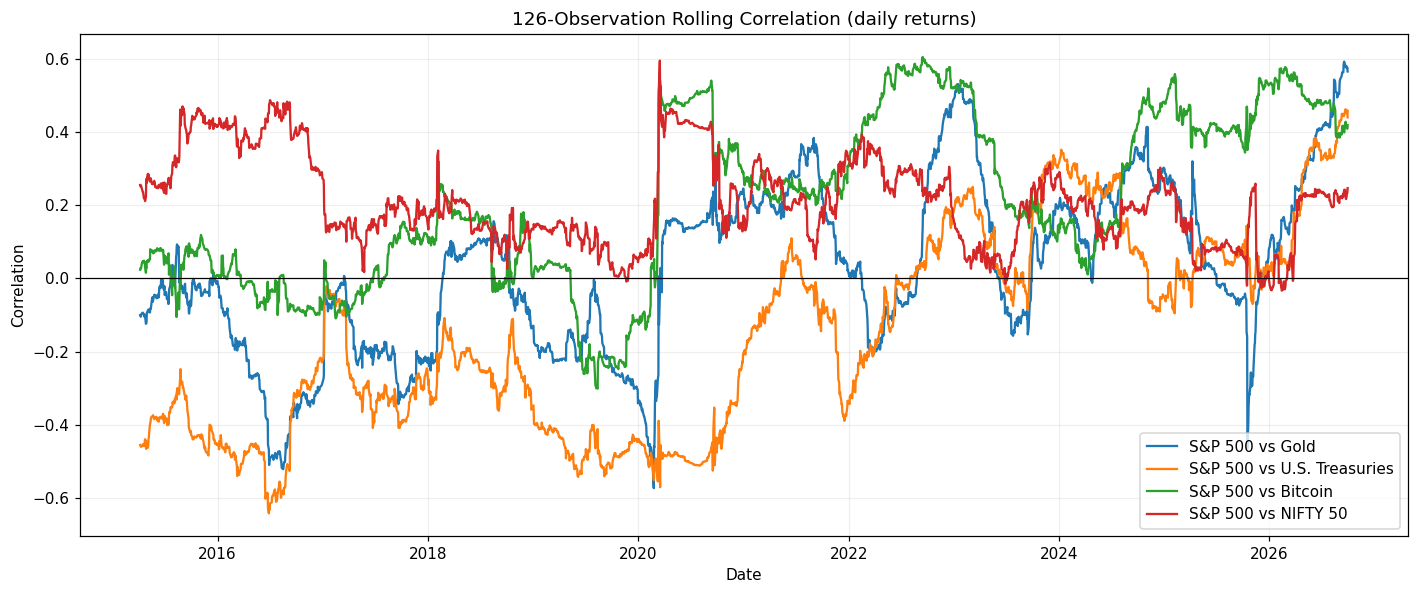

In [15]:
pairs = [("S&P 500", "Gold"), ("S&P 500", "U.S. Treasuries"), ("S&P 500", "Bitcoin"), ("S&P 500", "NIFTY 50")]
window = 126

fig, ax = plt.subplots(figsize=(13, 5.5))
for a, b in pairs:
    ax.plot(returns.index, returns[a].rolling(window).corr(returns[b]), label=f"{a} vs {b}")
ax.axhline(0, color="black", linewidth=0.8)
ax.set(title=f"{window}-Observation Rolling Correlation (daily returns)", ylabel="Correlation", xlabel="Date")
ax.legend()
plt.tight_layout()
plt.show()

In [16]:
# Is the diversification stable? S&P 500 correlation with each other asset, by calendar year (weekly returns)
yearly = {}
for yr, block in weekly_returns.groupby(weekly_returns.index.year):
    if len(block) >= 20:
        row = block.corr()["S&P 500"].drop("S&P 500")
        row["Weeks"] = len(block)
        yearly[yr] = row
# Each value rests on at most ~52 weekly observations, so individual cells are noisy (no confidence intervals).
by_year = pd.DataFrame(yearly).T.rename_axis("Year")
by_year["Weeks"] = by_year["Weeks"].astype(int)
by_year

,NIFTY 50,Gold,U.S. Treasuries,Bitcoin,Weeks
Year,,,,,
2015,0.3782,-0.0238,-0.3669,0.1338,52
2016,0.4738,-0.3870,-0.2817,-0.0350,53
2017,0.3772,-0.2010,-0.1900,0.0865,52
2018,0.3927,-0.0499,-0.2219,0.0260,52
2019,0.2232,-0.0833,-0.4693,-0.0638,52
2020,0.7432,0.4299,-0.2272,0.3089,52
2021,0.5388,0.3088,-0.3787,0.2196,53
2022,0.5593,0.2346,0.1220,0.4354,52
2023,0.4738,0.1435,0.3890,0.1191,52


## 9. Return distributions

Financial returns usually have heavier tails than a normal distribution. We report skewness, excess kurtosis (0 for a normal distribution), and the Jarque-Bera test (null hypothesis: returns are normal), and overlay a fitted normal curve on each histogram.

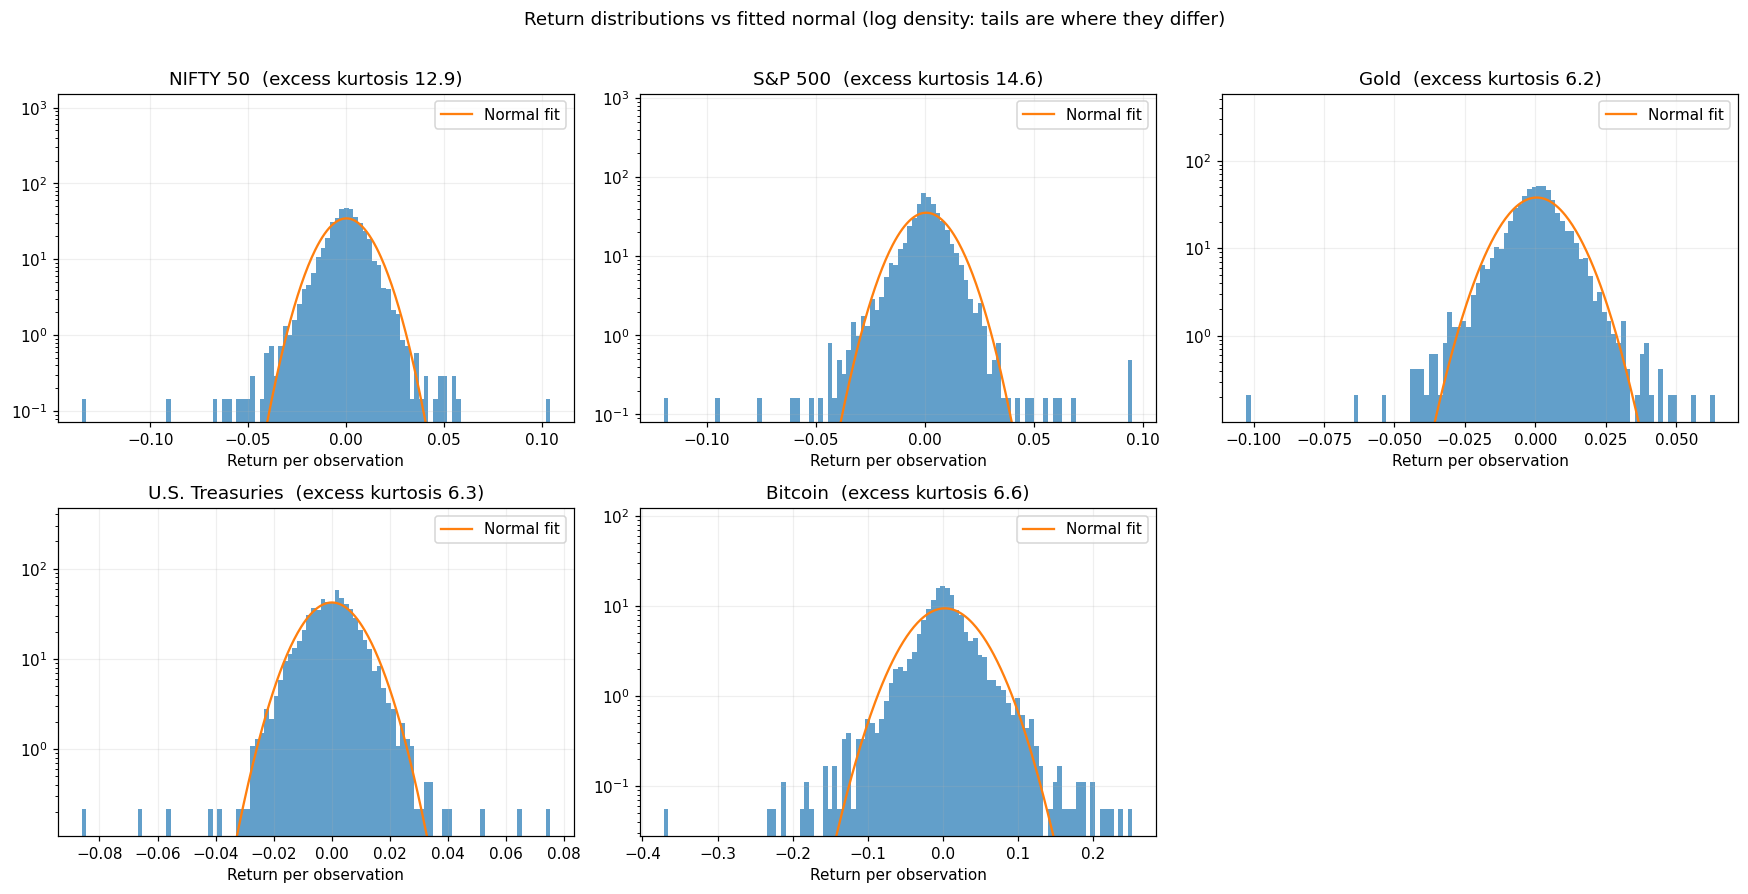

,Skewness,Excess kurtosis,Jarque-Bera p-value
NIFTY 50,-0.6766,12.8616,0.0000
S&P 500,-0.3454,14.6204,0.0000
Gold,-0.3737,6.2013,0.0000
U.S. Treasuries,-0.1035,6.3388,0.0000
Bitcoin,-0.0476,6.6096,0.0000


In [17]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, c in zip(axes.ravel(), returns.columns):
    r = returns[c]
    ax.hist(r, bins=100, density=True, alpha=0.7)
    xs = np.linspace(r.min(), r.max(), 400)
    ax.plot(xs, stats.norm.pdf(xs, r.mean(), r.std()), linewidth=1.5, label="Normal fit")
    ax.set_yscale("log")
    bin_width = (r.max() - r.min()) / 100
    ax.set_ylim(bottom=0.5 / (len(r) * bin_width))  # half an observation: the lowest meaningful density
    ax.set_title(f"{c}  (excess kurtosis {stats.kurtosis(r):.1f})")
    ax.set_xlabel("Return per observation")
    ax.legend()
for ax in axes.ravel()[len(returns.columns):]:
    ax.axis("off")
fig.suptitle("Return distributions vs fitted normal (log density: tails are where they differ)", y=1.01)
plt.tight_layout()
plt.show()

summary[["Skewness", "Excess kurtosis", "Jarque-Bera p-value"]]

## 10. Drawdowns

Investors experience losses from a previous peak, not just negative days:

$$
DD_t = \frac{W_t}{\max(W_0,\ldots,W_t)} - 1, \qquad W_0 = 1
$$

The series starts from the initial capital $W_0 = 1$, so a loss on the very first day is counted. We also report the longest stretch spent below a previous peak, measured from the date of the peak to the date of the new high (or to the last date in the sample if the spell is still open, which the table flags), plus the number of days it took to recover from the maximum drawdown when recovery occurred within the sample.


In [18]:
drawdowns = wealth0 / wealth0.cummax() - 1
max_drawdown = drawdowns.min()


def longest_underwater(dd):
    """Longest spell below a previous peak, measured peak date -> recovery date.
    Returns (days, recovered). If the spell is still open at the end of the
    sample it runs to the last date and recovered is False."""
    best_days, best_rec = 0, True
    peak, start, in_spell = dd.index[0], None, False
    for date, v in dd.items():
        if v < 0:
            if not in_spell:
                in_spell, start = True, peak
        else:
            if in_spell:
                days = (date - start).days
                if days > best_days:
                    best_days, best_rec = days, True
                in_spell = False
            peak = date
    if in_spell:
        days = (dd.index[-1] - start).days
        if days > best_days:
            best_days, best_rec = days, False
    return best_days, best_rec


def recovery_days(dd):
    trough_date = dd.idxmin()
    trough_value = dd.loc[trough_date]
    after_trough = dd.loc[trough_date:]
    recovered = after_trough[after_trough >= 0]
    if recovered.empty:
        return np.nan
    return int((recovered.index[0] - trough_date).days)


longest = {c: longest_underwater(drawdowns[c]) for c in drawdowns.columns}

dd_table = pd.DataFrame({
    "Maximum drawdown": max_drawdown,
    "Date of trough": drawdowns.idxmin(),
    "Longest time below peak (days)": pd.Series({c: v[0] for c, v in longest.items()}),
    "Longest spell recovered?": pd.Series({c: v[1] for c, v in longest.items()}),
    "Recovery from max drawdown (days)": drawdowns.apply(recovery_days),
    "Currently below peak by": drawdowns.iloc[-1],
}).sort_values("Maximum drawdown")
dd_table


,Maximum drawdown,Date of trough,Longest time below peak (days),Longest spell recovered?,Recovery from max drawdown (days),Currently below peak by
Bitcoin,-0.8304,2018-12-14,1080,True,719.0000,-0.3302
U.S. Treasuries,-0.4835,2023-10-19,2248,False,NaN,-0.4506
NIFTY 50,-0.4252,2020-03-23,1030,True,246.0000,-0.2488
S&P 500,-0.3379,2020-03-23,709,True,140.0000,-0.0172
Gold,-0.2640,2026-07-16,1306,True,NaN,-0.2320


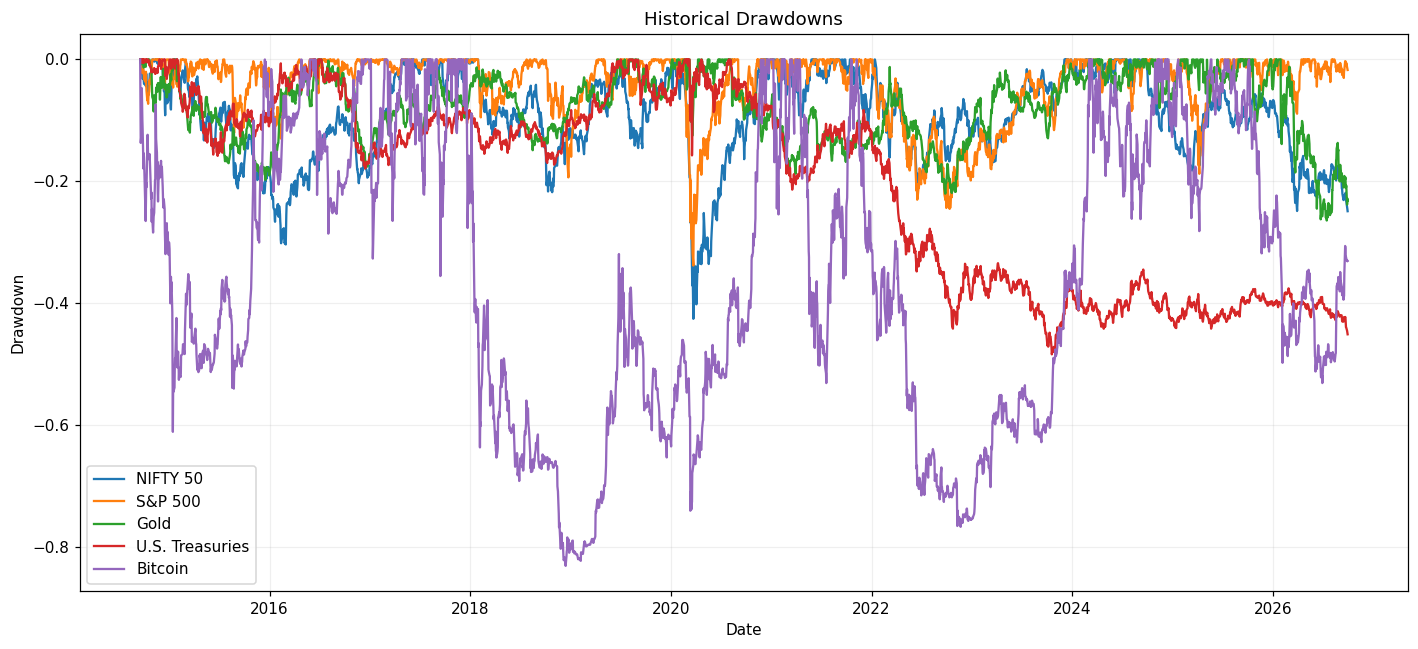

In [19]:
fig, ax = plt.subplots(figsize=(13, 6))
for c in drawdowns.columns:
    ax.plot(drawdowns.index, drawdowns[c], label=c)
ax.set(title="Historical Drawdowns", ylabel="Drawdown", xlabel="Date")
ax.legend()
plt.tight_layout()
plt.show()

## 11. Worst single-observation losses

In [20]:
pd.DataFrame({"Worst return": returns.min(), "Date": returns.idxmin()}).sort_values("Worst return")

,Worst return,Date
Bitcoin,-0.3717,2020-03-12
NIFTY 50,-0.1351,2020-03-23
S&P 500,-0.1198,2020-03-16
Gold,-0.1027,2026-01-30
U.S. Treasuries,-0.0862,2020-03-11


## 12. Tail risk: Value at Risk and Expected Shortfall

Historical VaR at confidence $c$ is the $(1-c)$ quantile of the empirical return distribution. It says *where* the bad tail begins but nothing about how bad it gets beyond that point. **Expected Shortfall (ES)** fills that gap: it is the average return on the observations that fall at or below the VaR threshold.

$$
\text{ES}_c = \mathbb{E}\left[\,r \mid r \le \text{VaR}_c\,\right]
$$

Values are returns per observation (negative = loss).

In [21]:
def hist_var(r, level):
    return r.quantile(1 - level)


def hist_es(r, level):
    q = hist_var(r, level)
    return r[r <= q].mean()


tail = pd.DataFrame({
    "VaR 95%": returns.apply(hist_var, level=0.95),
    "ES 95%": returns.apply(hist_es, level=0.95),
    "VaR 99%": returns.apply(hist_var, level=0.99),
    "ES 99%": returns.apply(hist_es, level=0.99),
}).sort_values("ES 99%")
tail

,VaR 95%,ES 95%,VaR 99%,ES 99%
Bitcoin,-0.0611,-0.0972,-0.1228,-0.1620
NIFTY 50,-0.0169,-0.0270,-0.0314,-0.0471
S&P 500,-0.0164,-0.0268,-0.0321,-0.0460
Gold,-0.0164,-0.0244,-0.0298,-0.0390
U.S. Treasuries,-0.0150,-0.0205,-0.0230,-0.0313


## 13. Risk-adjusted comparison

The Sharpe ratio uses the **arithmetic** mean excess return (the textbook definition), not CAGR:

$$
\text{Sharpe} = \frac{\bar r_{\text{excess}} \cdot N}{\sigma_{\text{obs}}\sqrt{N}}
$$

Here $\sigma_{\text{obs}}$ is the standard deviation of the series being measured (excess returns for the T-bill version, raw returns for the 0% version). Two versions are shown: with a 0% risk-free rate (the simplification of the original version), and with the actual 13-week U.S. T-bill yield, the appropriate risk-free rate for dollar-denominated returns. The **Calmar ratio** (CAGR divided by the size of the maximum drawdown) is added because it penalises exactly the deep losses Sharpe can miss.
Downside deviation is also reported as the annualised root-mean-square of excess returns below zero (shortfalls below the risk-free rate; all other observations count as zero). It is a complementary measure of downside variability, not a replacement for maximum drawdown.


In [22]:
excess = returns.sub(rf_obs, axis=0)

# Downside deviation: volatility of negative excess returns only.
downside = excess.clip(upper=0).pow(2).mean().pow(0.5) * np.sqrt(ANN)

sharpe_0 = returns.mean() * ANN / vol
sharpe_tb = excess.mean() * ANN / (excess.std() * np.sqrt(ANN))
calmar = cagr / max_drawdown.abs()

risk_adjusted = pd.DataFrame({
    "CAGR": cagr,
    "Annualised arithmetic mean": arith_mean,
    "Annualised volatility": vol,
    "Downside deviation": downside,
    "Sharpe (0% RF)": sharpe_0,
    "Sharpe (T-bill RF)": sharpe_tb,
    "Maximum drawdown": max_drawdown,
    "Calmar": calmar,
    "ES 95%": tail["ES 95%"],
})
print(f"Average T-bill yield over the sample: {tbill.mean():.2%}")
risk_adjusted.sort_values("Sharpe (T-bill RF)", ascending=False)


Average T-bill yield over the sample: 2.02%


,CAGR,Annualised arithmetic mean,Annualised volatility,Downside deviation,Sharpe (0% RF),Sharpe (T-bill RF),Maximum drawdown,Calmar,ES 95%
Bitcoin,0.5414,0.6488,0.6545,0.4388,0.9913,0.9605,-0.8304,0.6520,-0.0972
S&P 500,0.1374,0.1439,0.1735,0.1231,0.8293,0.7127,-0.3379,0.4067,-0.0268
Gold,0.1026,0.1109,0.1626,0.1148,0.6824,0.5582,-0.2640,0.3886,-0.0244
NIFTY 50,0.0502,0.0649,0.1778,0.1292,0.3648,0.2511,-0.4252,0.1180,-0.0270
U.S. Treasuries,-0.0031,0.0076,0.1463,0.1047,0.0523,-0.0859,-0.4835,-0.0063,-0.0205


In [23]:
# Does the ranking depend on how we measure performance?
ranks = pd.DataFrame({
    "by CAGR": cagr.rank(ascending=False),
    "by Sharpe (T-bill)": sharpe_tb.rank(ascending=False),
    "by Calmar": calmar.rank(ascending=False),
    "by (lowest) max drawdown": max_drawdown.abs().rank(ascending=True),
}).astype(int)
ranks.sort_values("by CAGR")

,by CAGR,by Sharpe (T-bill),by Calmar,by (lowest) max drawdown
Bitcoin,1,1,1,5
S&P 500,2,2,2,2
Gold,3,3,3,1
NIFTY 50,4,4,4,3
U.S. Treasuries,5,5,5,4


## 14. A compact risk/return map

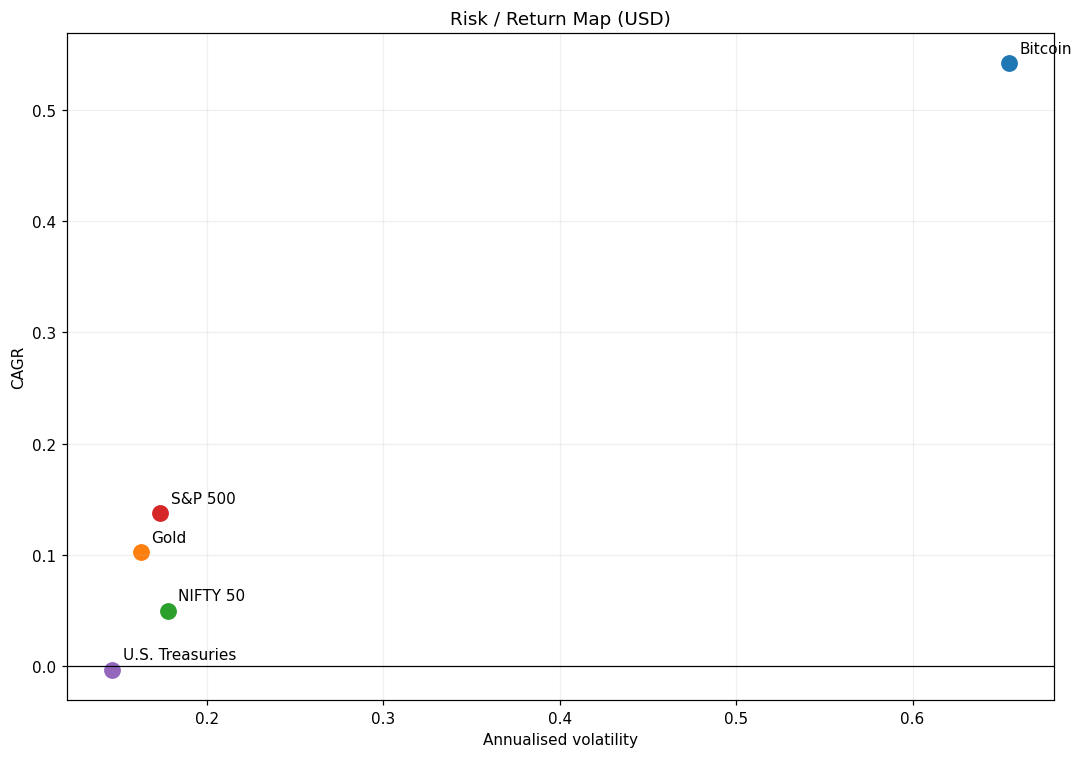

In [24]:
fig, ax = plt.subplots(figsize=(10, 7))
for asset in risk_adjusted.index:
    x, y = risk_adjusted.loc[asset, "Annualised volatility"], risk_adjusted.loc[asset, "CAGR"]
    ax.scatter(x, y, s=100)
    ax.annotate(asset, (x, y), xytext=(7, 7), textcoords="offset points")
ax.axhline(0, color="black", linewidth=0.8)
ax.set(title="Risk / Return Map (USD)", xlabel="Annualised volatility", ylabel="CAGR")
plt.tight_layout()
plt.show()

## 15. Robustness: what did the currency conversion change?

The same NIFTY series measured in rupees versus dollars. The difference is the INR/USD move, which is not an equity effect.

In [25]:
r_inr = nifty_inr.pct_change().dropna()
w_inr = (1 + r_inr).prod()

fx = pd.DataFrame({
    "NIFTY 50 in USD (used)": [cagr["NIFTY 50"], vol["NIFTY 50"], returns["NIFTY 50"].corr(returns["S&P 500"]),
                               weekly_returns["NIFTY 50"].corr(weekly_returns["S&P 500"])],
    "NIFTY 50 in INR": [w_inr ** (1 / years) - 1, r_inr.std() * np.sqrt(ANN),
                        r_inr.corr(returns["S&P 500"]),
                        nifty_inr.resample("W-FRI").last().dropna().pct_change().dropna().corr(weekly_returns["S&P 500"])],
}, index=["CAGR", "Annualised volatility", "Daily correlation with S&P 500", "Weekly correlation with S&P 500"])
fx

,NIFTY 50 in USD (used),NIFTY 50 in INR
CAGR,0.0502,0.0905
Annualised volatility,0.1778,0.1583
Daily correlation with S&P 500,0.2621,0.2992
Weekly correlation with S&P 500,0.5196,0.5375


## 16. Findings

The text below is **generated from the tables above**, so it always matches the data. Read it as a starting point and edit it into your own conclusions.

In [26]:
def pct(x):
    return f"{x:.1%}"


best, worst = cagr.idxmax(), cagr.idxmin()
rho, _ = stats.spearmanr(vol, cagr)
deep = max_drawdown.sort_values().head(2)
others_corr = corr_weekly.where(~np.eye(len(corr_weekly), dtype=bool)).mean().sort_values()
neg_vs_spx = corr_weekly["S&P 500"].drop("S&P 500")
neg_vs_spx = neg_vs_spx[neg_vs_spx < 0.1]
ex_k = summary["Excess kurtosis"].sort_values(ascending=False)
n_nonnormal = int((summary["Jarque-Bera p-value"] < 0.01).sum())

print(f"Sample: {prices.index[0].date()} to {prices.index[-1].date()} ({years:.1f} years, USD terms).\n")

print(f"Q1. Strongest compounded performance: {best} (CAGR {pct(cagr[best])}); weakest: {worst} ({pct(cagr[worst])}).")

print(f"\nQ2. Rank correlation between volatility and CAGR across the five assets: {rho:+.2f}. "
      + ("Higher volatility came with higher returns here, but with only 5 assets this is anecdote, not evidence."
         if rho > 0.5 else
         "Higher volatility did NOT reliably come with higher returns in this sample."))

print(f"\nQ3. Deepest drawdowns: {deep.index[0]} ({pct(deep.iloc[0])}) and {deep.index[1]} ({pct(deep.iloc[1])}).")

print(f"\nQ4. Lowest average weekly correlation with the other assets: {others_corr.index[0]} ({others_corr.iloc[0]:+.2f}).")
if len(neg_vs_spx):
    print("    Weekly correlation with the S&P 500 below 0.10: "
          + ", ".join(f"{k} ({v:+.2f})" for k, v in neg_vs_spx.items()) + ".")
else:
    print("    No asset had weekly correlation with the S&P 500 below 0.10.")
print("    Check the by-year table in section 8 before treating any of these as stable diversifiers.")

print(f"\nQ5. Heaviest tails: {ex_k.index[0]} (excess kurtosis {ex_k.iloc[0]:.1f}); "
      f"Jarque-Bera rejects normality at the 1% level for {n_nonnormal} of {len(summary)} assets.")

orders = {
    "CAGR": list(cagr.sort_values(ascending=False).index),
    "Sharpe (T-bill)": list(sharpe_tb.sort_values(ascending=False).index),
    "Calmar": list(calmar.sort_values(ascending=False).index),
}
print("\nQ6. Rankings by metric:")
for k, v in orders.items():
    print(f"    {k:16s}: " + " > ".join(v))
print("    Top asset " + ("is the same" if len({v[0] for v in orders.values()}) == 1 else "CHANGES") + " across the three measures.")

print("\nCurrency check: NIFTY CAGR in USD "
      f"{pct(cagr['NIFTY 50'])} vs {pct(fx.loc['CAGR', 'NIFTY 50 in INR'])} in INR.")

Sample: 2014-09-17 to 2026-09-30 (12.0 years, USD terms).

Q1. Strongest compounded performance: Bitcoin (CAGR 54.1%); weakest: U.S. Treasuries (-0.3%).

Q2. Rank correlation between volatility and CAGR across the five assets: +0.70. Higher volatility came with higher returns here, but with only 5 assets this is anecdote, not evidence.

Q3. Deepest drawdowns: Bitcoin (-83.0%) and U.S. Treasuries (-48.4%).

Q4. Lowest average weekly correlation with the other assets: U.S. Treasuries (+0.05).
    Weekly correlation with the S&P 500 below 0.10: U.S. Treasuries (-0.10).
    Check the by-year table in section 8 before treating any of these as stable diversifiers.

Q5. Heaviest tails: S&P 500 (excess kurtosis 14.6); Jarque-Bera rejects normality at the 1% level for 5 of 5 assets.

Q6. Rankings by metric:
    CAGR            : Bitcoin > S&P 500 > Gold > NIFTY 50 > U.S. Treasuries
    Sharpe (T-bill) : Bitcoin > S&P 500 > Gold > NIFTY 50 > U.S. Treasuries
    Calmar          : Bitcoin > S&P 50

## 17. Limitations

What this version **fixes** compared with a naive price-chart comparison: NIFTY is converted to USD; compound returns use CAGR rather than an averaged daily return; annualisation uses the sample's actual observation frequency; dividends are included for the S&P 500 (when `^SP500TR` is available), TLT and GLD; a real risk-free rate is used; correlations are shown at a weekly horizon to reduce time-zone distortion; the sample window is fixed.

What **remains**:

1. **NIFTY is still a price index** (dividends excluded), so its return is understated by roughly its dividend yield (typically on the order of 1% a year) relative to the total-return series. Yahoo does not provide a reliable NIFTY total-return series.
2. **Weekly returns reduce but do not eliminate** non-synchronicity, and cut the number of observations by about five.
3. **GLD and TLT are ETF proxies**, not pure asset-class indices; GLD returns are net of fees.
4. **Historical relationships may not persist**; the sample covers several regimes but not all possible ones.
5. **Bitcoin has a short history**, so its statistics are dominated by a few boom-and-bust episodes.
6. **Historical VaR/ES are only as good as the sample's tail** and cannot describe events that have not yet happened.
7. **FX and equity timestamps differ slightly** (Yahoo's `INR=X` fix is not taken at the NIFTY close).
8. **Descriptive statistics only**: no transaction costs, taxes, liquidity limits, or portfolio weights, and no confidence intervals on the estimates.
9. **Data comes from Yahoo Finance**, an unofficial source that occasionally has errors or revisions. The committed snapshot freezes one version.
10. **Returns cover unequal calendar intervals.** After the inner join, Monday and post-holiday returns span several days. This slightly inflates kurtosis and tail measures relative to uniform daily data.
11. **The inner join discards Bitcoin's weekend trading** (about 30% of its days), so Bitcoin's weekend moves enter only through Monday's multi-day return.
12. **Year-by-year correlations are noisy.** Each cell rests on at most about 52 weekly observations, and no confidence intervals are reported.


## 18. Extensions

* build and optimise a multi-asset portfolio
* bootstrap confidence intervals for the statistics above
* rolling Sharpe ratios and regime-conditional correlations
* factor exposure analysis
* backtesting framework
* browser-based portfolio analytics app

## Final takeaway

The important result is not a particular asset ranking but the framework:

**Price → Return → Distribution → Risk → Correlation → Drawdown → Risk-adjusted performance**

and the discipline of checking, at every step, whether the numbers are comparable across assets (same currency, same return basis, same time horizon).